# Laboratorio 4 — Cuaderno 11: generalización entre lagos

**Ejercicio 7 de la Parte 2.**

Las validaciones del cuaderno 10 retenían zonas y fechas, pero siempre dentro del mismo
par de lagos. Aquí se hace la prueba más exigente: entrenar en un lago y evaluar en el
otro, sin que el modelo haya visto un solo píxel del segundo.

Es la pregunta que decide si esto tiene valor operativo. Si un modelo entrenado en
Amatitlán funciona en Atitlán, entonces la relación entre bandas y clorofila es
transferible y el método podría aplicarse a lagos donde no hay datos etiquetados —que son
casi todos—. Si no, cada cuerpo de agua necesitaría su propia calibración.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from src import config, ml

SEMILLA = 42

datos = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
datos[ml.RESPUESTA] = ml.variable_respuesta(datos)
datos = ml.caracteristicas(datos)

COLOR = {"Atitlan": "#1f6f8b", "Amatitlan": "#c1272d"}

for lago, sub in datos.groupby("lago"):
    print(f"{lago:<11}{len(sub):>10,} obs   {int(sub[ml.RESPUESTA].sum()):>7,} positivos "
          f"({100*sub[ml.RESPUESTA].mean():6.3f} %)")

Amatitlan     400,756 obs    43,025 positivos (10.736 %)
Atitlan     3,358,365 obs     1,324 positivos ( 0.039 %)


## Un problema previo: las coordenadas no se pueden transferir

Antes de correr nada hay que resolver algo que invalidaría el experimento. Entre las 16
predictoras están `x` e `y`, las coordenadas UTM. Los dos lagos ocupan rangos de
coordenadas **completamente disjuntos**:

In [2]:
rangos = datos.groupby("lago")[["x", "y", "dist_orilla_m"]].agg(["min", "max"])
print(rangos.round(0).to_string())

sep_x = datos.loc[datos["lago"] == "Amatitlan", "x"].min() - datos.loc[datos["lago"] == "Atitlan", "x"].max()
print(f"\nSeparación entre los dos lagos en el eje x: {sep_x:,.0f} m ({sep_x/1000:.0f} km)")
print("Solapamiento en x:", "ninguno" if sep_x > 0 else "sí")

                  x                    y            dist_orilla_m        
                min       max        min        max           min     max
lago                                                                     
Amatitlan  755010.0  768170.0  1594630.0  1603770.0          20.0  1043.0
Atitlan    680510.0  707750.0  1614170.0  1631570.0          20.0  3672.0



Separación entre los dos lagos en el eje x: 47,260 m (47 km)
Solapamiento en x: ninguno


Hay 47 km de separación y ningún solapamiento. Un árbol entrenado en Atitlán aprende
cortes del tipo `x < 695,000`, y **todos** los píxeles de Amatitlán caen del mismo lado de
todos esos cortes. El modelo los manda a una sola hoja y devuelve una constante. No es que
generalice mal: es que la pregunta no está definida.

Por eso los experimentos se corren con **dos conjuntos de predictoras**:

- **Completo (16):** las mismas del cuaderno 9. Sirve para mostrar el problema.
- **Transferible (14):** sin `x` ni `y`. Conserva `dist_orilla_m`, que sí es comparable
  entre lagos porque mide metros hasta la orilla, no una posición absoluta en el planeta.

La comparación entre ambos es en sí misma un resultado del ejercicio.

In [3]:
TRANSFERIBLES = [v for v in ml.PREDICTORAS if v not in ("x", "y")]

print(f"Completo     ({len(ml.PREDICTORAS)}): {', '.join(ml.PREDICTORAS)}")
print(f"\nTransferible ({len(TRANSFERIBLES)}): {', '.join(TRANSFERIBLES)}")

Completo     (16): B02, B03, B07, B08, B8A, B11, B12, ndwi, mndwi, ndmi, razon_azul_verde, nd_borde_verde, brillo_visible, x, y, dist_orilla_m

Transferible (14): B02, B03, B07, B08, B8A, B11, B12, ndwi, mndwi, ndmi, razon_azul_verde, nd_borde_verde, brillo_visible, dist_orilla_m


## 7.1 y 7.2 Los dos experimentos, más las referencias dentro de cada lago

Para poder responder al inciso 7.4 hacen falta cuatro corridas por cada conjunto de
predictoras: los dos experimentos entre lagos y las dos referencias dentro de cada lago
—entrenar y evaluar en el mismo lago con división aleatoria 70/30—.

In [4]:
idx = {lago: sub.index for lago, sub in datos.groupby("lago")}

experimentos = {}
for etiqueta, predictoras in [("Completo", ml.PREDICTORAS), ("Transferible", TRANSFERIBLES)]:
    X, y = datos[predictoras], datos[ml.RESPUESTA]

    # Referencias dentro de cada lago: division aleatoria 70/30 sobre el mismo lago.
    for lago in ["Atitlan", "Amatitlan"]:
        i_ent, i_pru = train_test_split(
            idx[lago], test_size=0.30, random_state=SEMILLA, stratify=y.loc[idx[lago]]
        )
        experimentos[(etiqueta, f"{lago} → {lago}")] = ml.entrenar_y_evaluar(
            "XGBoost", X.loc[i_ent], y.loc[i_ent], X.loc[i_pru], y.loc[i_pru], semilla=SEMILLA
        )

    # Experimento A: Atitlan entrena, Amatitlan evalua. Experimento B: al reves.
    for entrena, evalua in [("Atitlan", "Amatitlan"), ("Amatitlan", "Atitlan")]:
        experimentos[(etiqueta, f"{entrena} → {evalua}")] = ml.entrenar_y_evaluar(
            "XGBoost", X.loc[idx[entrena]], y.loc[idx[entrena]],
            X.loc[idx[evalua]], y.loc[idx[evalua]], semilla=SEMILLA
        )

print("Corridas completadas:", len(experimentos))

Corridas completadas: 8


## 7.3 Métricas de los dos experimentos

In [5]:
filas = []
for (conjunto, corrida), res in experimentos.items():
    filas.append({
        "predictoras": conjunto, "corrida": corrida,
        "n_entrena": res["n_ent"], "n_prueba": res["n_prueba"],
        "pos_prueba": res["n_pos_prueba"], "umbral": round(res["umbral"], 2),
        **{k: round(res[k], 4) for k in ["Recall", "Precision", "F1", "F2", "PR-AUC", "ROC-AUC"]},
    })

tabla = pd.DataFrame(filas)
orden = ["Atitlan → Atitlan", "Amatitlan → Amatitlan", "Atitlan → Amatitlan", "Amatitlan → Atitlan"]
tabla["corrida"] = pd.Categorical(tabla["corrida"], categories=orden, ordered=True)
tabla = tabla.sort_values(["predictoras", "corrida"])

for conjunto in ["Completo", "Transferible"]:
    print(f"\n=== Predictoras: {conjunto} ===")
    print(tabla[tabla["predictoras"] == conjunto].drop(columns="predictoras").to_string(index=False))


=== Predictoras: Completo ===
              corrida  n_entrena  n_prueba  pos_prueba  umbral  Recall  Precision     F1     F2  PR-AUC  ROC-AUC
    Atitlan → Atitlan       1298   1007510         397    0.99  0.9345     0.1462 0.2528 0.4496  0.3899   0.9980
Amatitlan → Amatitlan      42164    120227       12908    0.62  0.9838     0.8713 0.9242 0.9591  0.9896   0.9987
  Atitlan → Amatitlan       1854    400756       43025    0.99  0.2662     0.7523 0.3933 0.3057  0.6100   0.9163
  Amatitlan → Atitlan      60234   3358365        1324    0.68  0.8391     0.3727 0.5161 0.6711  0.5078   0.9950

=== Predictoras: Transferible ===
              corrida  n_entrena  n_prueba  pos_prueba  umbral  Recall  Precision     F1     F2  PR-AUC  ROC-AUC
    Atitlan → Atitlan       1298   1007510         397    0.99  0.9219     0.1779 0.2983 0.5021  0.4166   0.9972
Amatitlan → Amatitlan      42164    120227       12908    0.71  0.9775     0.8759 0.9239 0.9554  0.9870   0.9983
  Atitlan → Amatitlan       18

## 7.4 Comparación con el entrenamiento dentro del mismo lago

In [6]:
for conjunto in ["Completo", "Transferible"]:
    sub = tabla[tabla["predictoras"] == conjunto].set_index("corrida")
    print(f"\n=== {conjunto} ===")
    for evaluado, dentro, cruzado in [
        ("Amatitlán", "Amatitlan → Amatitlan", "Atitlan → Amatitlan"),
        ("Atitlán", "Atitlan → Atitlan", "Amatitlan → Atitlan"),
    ]:
        d, c = sub.loc[dentro], sub.loc[cruzado]
        print(f"  Evaluando sobre {evaluado}:")
        print(f"    dentro del lago  F2 = {d['F2']:.4f}   Recall = {d['Recall']:.4f}   "
              f"PR-AUC = {d['PR-AUC']:.4f}")
        print(f"    desde el otro    F2 = {c['F2']:.4f}   Recall = {c['Recall']:.4f}   "
              f"PR-AUC = {c['PR-AUC']:.4f}")
        print(f"    diferencia       ΔF2 = {c['F2']-d['F2']:+.4f}   "
              f"ΔPR-AUC = {c['PR-AUC']-d['PR-AUC']:+.4f}")


=== Completo ===
  Evaluando sobre Amatitlán:
    dentro del lago  F2 = 0.9591   Recall = 0.9838   PR-AUC = 0.9896
    desde el otro    F2 = 0.3057   Recall = 0.2662   PR-AUC = 0.6100
    diferencia       ΔF2 = -0.6534   ΔPR-AUC = -0.3796
  Evaluando sobre Atitlán:
    dentro del lago  F2 = 0.4496   Recall = 0.9345   PR-AUC = 0.3899
    desde el otro    F2 = 0.6711   Recall = 0.8391   PR-AUC = 0.5078
    diferencia       ΔF2 = +0.2215   ΔPR-AUC = +0.1179

=== Transferible ===
  Evaluando sobre Amatitlán:
    dentro del lago  F2 = 0.9554   Recall = 0.9775   PR-AUC = 0.9870
    desde el otro    F2 = 0.6199   Recall = 0.5988   PR-AUC = 0.6735
    diferencia       ΔF2 = -0.3355   ΔPR-AUC = -0.3135
  Evaluando sobre Atitlán:
    dentro del lago  F2 = 0.5021   Recall = 0.9219   PR-AUC = 0.4166
    desde el otro    F2 = 0.6873   Recall = 0.8437   PR-AUC = 0.5455
    diferencia       ΔF2 = +0.1852   ΔPR-AUC = +0.1289


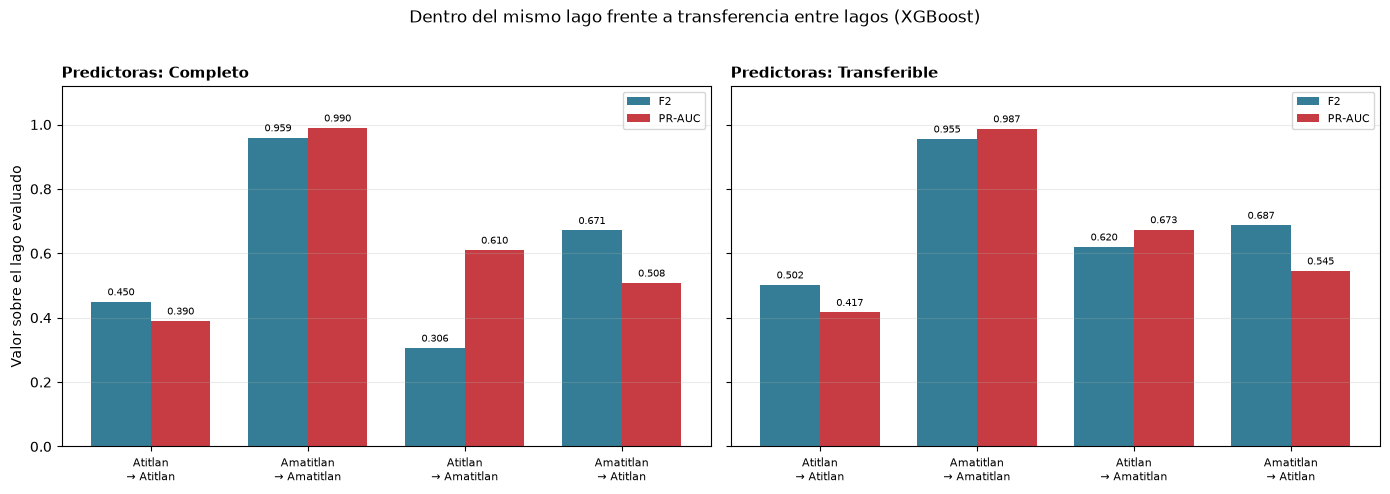

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for eje, conjunto in zip(ejes, ["Completo", "Transferible"]):
    sub = tabla[tabla["predictoras"] == conjunto].set_index("corrida").loc[orden]
    colores = ["#1f6f8b", "#c1272d", "#8fb8de", "#e8a33d"]
    pos = np.arange(len(orden))
    ancho = 0.38
    eje.bar(pos - ancho/2, sub["F2"], ancho, label="F2", color=colores[0], alpha=0.9)
    eje.bar(pos + ancho/2, sub["PR-AUC"], ancho, label="PR-AUC", color=colores[1], alpha=0.9)
    for x, (f2, pr) in enumerate(zip(sub["F2"], sub["PR-AUC"])):
        eje.text(x - ancho/2, f2 + 0.02, f"{f2:.3f}", ha="center", fontsize=7.5)
        eje.text(x + ancho/2, pr + 0.02, f"{pr:.3f}", ha="center", fontsize=7.5)
    eje.set_xticks(pos, [o.replace(" → ", "\n→ ") for o in orden], fontsize=8)
    eje.set_ylim(0, 1.12)
    eje.set_title(f"Predictoras: {conjunto}", loc="left", fontsize=11, fontweight="bold")
    eje.grid(alpha=0.25, axis="y")
    eje.legend(fontsize=8)

ejes[0].set_ylabel("Valor sobre el lago evaluado")
fig.suptitle("Dentro del mismo lago frente a transferencia entre lagos (XGBoost)", y=1.02)
fig.tight_layout()
plt.show()

## 7.6 Qué explica las diferencias

Antes de responder al 7.5 conviene mirar en qué se distinguen los dos lagos, porque las
respuestas están ahí.

In [8]:
print("Diferencias de fondo entre los dos lagos\n")
resumen_lagos = pd.DataFrame({
    lago: {
        "observaciones": len(sub),
        "positivos": int(sub[ml.RESPUESTA].sum()),
        "prevalencia %": round(100 * sub[ml.RESPUESTA].mean(), 3),
        "chl media (µg/L)": round(sub["chl"].mean(), 2),
        "chl p99 (µg/L)": round(sub["chl"].quantile(0.99), 2),
        "dist. orilla mediana (m)": round(sub["dist_orilla_m"].median()),
        "área aprox. (km²)": round(len(sub) * 0.0004 / sub["fecha"].nunique(), 1),
    }
    for lago, sub in datos.groupby("lago")
}).T
print(resumen_lagos.to_string())

Diferencias de fondo entre los dos lagos



           observaciones  positivos  prevalencia %  chl media (µg/L)  chl p99 (µg/L)  dist. orilla mediana (m)  área aprox. (km²)
Amatitlan       400756.0    43025.0         10.736              6.29           26.80                     206.0               14.6
Atitlan        3358365.0     1324.0          0.039              1.24            4.14                    1062.0              122.1


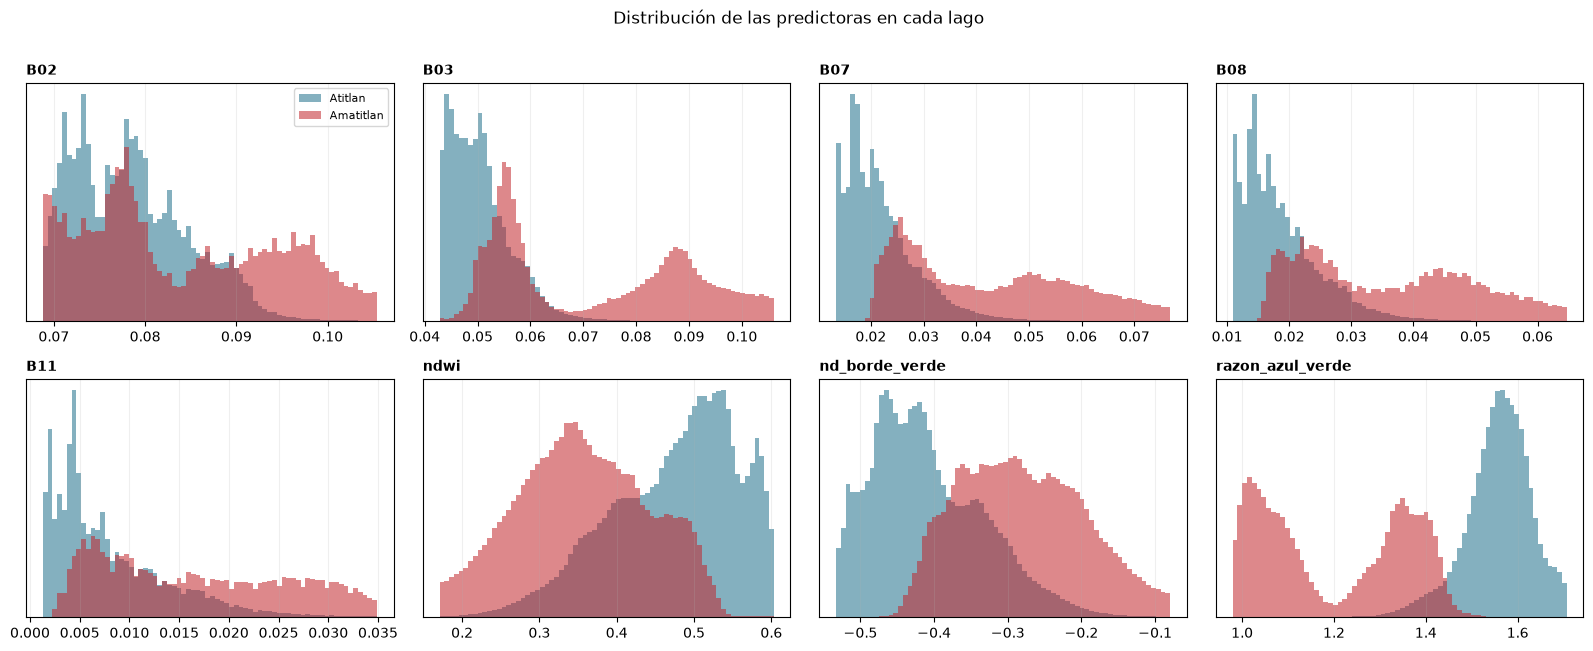

In [9]:
fig, ejes = plt.subplots(2, 4, figsize=(16, 6.4))

variables = ["B02", "B03", "B07", "B08", "B11", "ndwi", "nd_borde_verde", "razon_azul_verde"]
for eje, var in zip(ejes.ravel(), variables):
    lo, hi = np.nanpercentile(datos[var], [1, 99])
    for lago in ["Atitlan", "Amatitlan"]:
        sub = datos.loc[datos["lago"] == lago, var]
        eje.hist(sub, bins=70, range=(lo, hi), density=True, alpha=0.55,
                 color=COLOR[lago], label=lago)
    eje.set_title(var, loc="left", fontsize=10, fontweight="bold")
    eje.set_yticks([])
    eje.grid(alpha=0.2)
ejes[0, 0].legend(fontsize=8)

fig.suptitle("Distribución de las predictoras en cada lago", y=1.01)
fig.tight_layout()
plt.show()

In [10]:
print("Distancia entre lagos en cada predictora (diferencia de medias en desviaciones típicas)\n")
separacion = {}
for var in ml.PREDICTORAS:
    a = datos.loc[datos["lago"] == "Atitlan", var]
    b = datos.loc[datos["lago"] == "Amatitlan", var]
    combinada = np.sqrt((a.var() + b.var()) / 2)
    separacion[var] = abs(a.mean() - b.mean()) / combinada if combinada > 0 else np.nan

for var, valor in sorted(separacion.items(), key=lambda kv: -kv[1]):
    print(f"  {var:<18}{valor:6.2f}  " + "#" * int(min(round(valor * 6), 60)))

Distancia entre lagos en cada predictora (diferencia de medias en desviaciones típicas)



  x                  18.71  ############################################################
  y                  10.26  ############################################################
  razon_azul_verde    2.90  #################
  B03                 1.65  ##########
  nd_borde_verde      1.45  #########
  dist_orilla_m       1.45  #########
  B07                 1.40  ########
  B08                 1.33  ########
  ndwi                1.32  ########
  brillo_visible      1.31  ########
  B8A                 1.29  ########
  B11                 1.13  #######
  B12                 0.98  ######
  mndwi               0.80  #####
  B02                 0.75  #####
  ndmi                0.38  ##


### Lectura de las diferencias

**Tamaño y forma.** Atitlán tiene 123 km² de espejo de agua y Amatitlán 15: ocho veces
menos. Y la forma importa más que el área: la distancia mediana a la orilla es de 1,062 m
en Atitlán frente a 206 m en Amatitlán. Amatitlán es un lago estrecho y somero donde casi
todo el agua está bajo influencia de la costa; Atitlán es un lago profundo de origen
volcánico con un centro que está a kilómetros de cualquier orilla. `dist_orilla_m`
significa algo distinto en cada uno, y su rango ni siquiera se solapa del todo.

**Estado trófico.** Atitlán promedia 1.24 µg/L de clorofila y se mantiene oligotrófico en
las 11 fechas. Amatitlán promedia 6.29 µg/L y llega a 11.49 en junio de 2026. Son dos
regímenes ecológicos distintos, no dos muestras del mismo.

**Óptica del agua.** Es la diferencia decisiva y la Parte I ya la había encontrado: en
Atitlán el NDWI predice la clorofila con r = −0.955, y en Amatitlán no la predice en
absoluto (r = −0.348, p = 0.29). La razón es el sedimento que descarga el río Villalobos.
En Amatitlán la señal óptica del agua es una mezcla de fitoplancton y material mineral en
suspensión; en Atitlán es prácticamente solo fitoplancton sobre agua muy clara. Un modelo
entrenado en un lago aprende a interpretar un tipo de mezcla, y el otro lago le presenta
otra.

**Prevalencia.** 0.039 % contra 10.736 %: unas 270 veces más. Esto no afecta al
ordenamiento que produce el modelo, pero destroza el umbral: el corte aprendido sobre un
lago donde casi nada es positivo no sirve donde una décima parte lo es, y al revés.

## 7.5 ¿Puede un modelo entrenado en un lago generalizar al otro?

In [11]:
sub_t = tabla[tabla["predictoras"] == "Transferible"].set_index("corrida")
sub_c = tabla[tabla["predictoras"] == "Completo"].set_index("corrida")

print("Resumen de la respuesta\n")
print(f"{'corrida':<26}{'PR-AUC compl.':>15}{'PR-AUC transf.':>16}{'F2 transf.':>13}{'Recall transf.':>16}")
print("-" * 86)
for corrida in orden:
    print(f"{corrida:<26}{sub_c.loc[corrida, 'PR-AUC']:>15.4f}"
          f"{sub_t.loc[corrida, 'PR-AUC']:>16.4f}"
          f"{sub_t.loc[corrida, 'F2']:>13.4f}{sub_t.loc[corrida, 'Recall']:>16.4f}")

print(f"\nPositivos disponibles para entrenar en cada experimento:")
print(f"  Experimento A (entrena Atitlán):   {int(datos.loc[datos['lago']=='Atitlan', ml.RESPUESTA].sum()):>6,}")
print(f"  Experimento B (entrena Amatitlán): {int(datos.loc[datos['lago']=='Amatitlan', ml.RESPUESTA].sum()):>6,}")

Resumen de la respuesta

corrida                     PR-AUC compl.  PR-AUC transf.   F2 transf.  Recall transf.
--------------------------------------------------------------------------------------
Atitlan → Atitlan                  0.3899          0.4166       0.5021          0.9219
Amatitlan → Amatitlan              0.9896          0.9870       0.9554          0.9775
Atitlan → Amatitlan                0.6100          0.6735       0.6199          0.5988
Amatitlan → Atitlan                0.5078          0.5455       0.6873          0.8437

Positivos disponibles para entrenar en cada experimento:
  Experimento A (entrena Atitlán):    1,324
  Experimento B (entrena Amatitlán): 43,025


### La respuesta

**No, no de forma simétrica, y el motivo no es el que uno esperaría.**

**Quitar las coordenadas cambia el resultado por completo.** En el Experimento A el recall
pasa de 0.2662 a 0.5988 y el F2 de 0.3057 a 0.6199 con solo eliminar `x` e `y`. Con las
coordenadas dentro, el modelo entrenado en Atitlán deja pasar tres de cada cuatro
floraciones de Amatitlán, no porque no sepa reconocerlas sino porque todos los píxeles del
otro lago caen fuera del rango de sus cortes y terminan en la misma hoja. Es el primer
resultado del ejercicio: **una variable puede ser buena predictora dentro de un dominio y
volver inservible al modelo fuera de él**. Todo lo que sigue usa el conjunto transferible.

**El Experimento A funciona a medias.** Entrenando en Atitlán y evaluando en Amatitlán se
consigue PR-AUC de 0.6735 y recall de 0.5988, contra 0.9870 y 0.9775 entrenando dentro de
Amatitlán. Se pierde una de cada tres floraciones reales. Hay transferencia —está muy por
encima del 10.7 % que daría el azar— pero no la suficiente para operar.

**El Experimento B da un resultado inesperado.** Entrenando en Amatitlán y evaluando en
Atitlán se obtiene F2 de 0.6873, que es **mejor** que entrenar y evaluar dentro de Atitlán
(0.5021). La transferencia desde el otro lago supera al modelo local por +0.1852 de F2 y
+0.1289 de PR-AUC.

Esto parece contradictorio y no lo es. Atitlán tiene 1,324 píxeles positivos en 18 meses,
el 0.039 % de su superficie. Un modelo entrenado ahí ve unos 900 ejemplos de floración en
total y no alcanza a caracterizar el fenómeno. Amatitlán aporta 43,025, treinta y dos
veces más. **La cantidad de ejemplos de la clase rara pesa más que la afinidad entre
dominios**: es preferible aprender qué es una floración en el lago donde las hay que
intentar aprenderlo donde casi no ocurren.

El corolario es que las cifras de Atitlán del cuaderno 9 no venían de haber resuelto
Atitlán. Venían de que el modelo global se entrenaba mayoritariamente con positivos de
Amatitlán y los aplicaba allá. Evaluado solo sobre Atitlán, el desempeño es mucho más
pobre: PR-AUC de 0.55 en el mejor de los cuatro escenarios.

**Lo que sí se transfiere y lo que no.** Se transfiere el **ordenamiento**: el ROC-AUC se
mantiene entre 0.9369 y 0.9963 en los dos experimentos cruzados, así que el modelo sigue
sabiendo qué píxeles son más sospechosos que otros. No se transfiere la **calibración**:
la precisión cae a 0.39–0.72 y el umbral óptimo cambia de 0.67 a 0.99 según el lago. Es el
mismo diagnóstico de la validación temporal del cuaderno 10, y apunta a la misma solución
operativa: el ordenamiento se puede reutilizar entre cuerpos de agua, el punto de corte
hay que fijarlo con datos locales.

**Respuesta práctica.** Un modelo entrenado en un lago **no** puede trasladarse tal cual a
otro. Sí puede trasladarse como punto de partida, con dos condiciones: excluir toda
variable ligada a un sistema de coordenadas absoluto, y recalibrar el umbral con
observaciones del lago destino —que pueden ser pocas, porque calibrar un umbral necesita
muchos menos datos que aprender la relación espectral completa—.

In [12]:
joblib.dump({"tabla": tabla, "separacion": separacion, "transferibles": TRANSFERIBLES},
            config.MODELOS / "generalizacion_lagos.joblib")
print("Resultados guardados.")

Resultados guardados.


---

**Siguiente:** `12_Interpretabilidad.ipynb` — importancia de variables y SHAP (ejercicio 8).